### Deep learning model training.
#### Top accuracy(inner 256x256):
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|89.7%|92.9%|20260316|    
|U2Net|89.8%|93.2%|20260216|    
|U2Net_cbam|89.8%|93.4%|20260307|    
|U2Net_biatt|89.9%|93.1%|20260306|    
|||||    

#### Top accuracy(full patch size：448x448):
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|80.3%|86.1%|20260428|    
|U2Net|90.6%|94.4%|20260427|    
|U2Net_cbam|90.6%|94.5%|20260428|    
|U2Net_biatt|90.7%|95.9%|20260428|    
|||||  


#### Top accuracy(full patch size：512x512):
|model|miou|oa|update_time||    
|----|----|----|----|---|
|UNet|92.8%|96.2%|20260309|difficult to train|    
|U2Net|93.0%|96.4%|20260309||    
|U2Net_cbam|93.0%|96.4%|20260309||    
|U2Net_biatt|92.8%|96.3%|20260308||    
|||||    


### conclusions:   
1. larger patch size achieves better performance.
2. the bn params should be frozen or remove bn layer  when train unet. 



In [1]:
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.imgShow import imsShow
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.dataloader import read_scenes 
from utils.metrics import oa_binary, miou_binary
from utils.dataloader import SceneArraySet, PatchPathSet
from model import unet, u2net_biatt, u2net, u2net_cbam


In [2]:
patch_size = 512  ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
paths_dem_tra = config.paths_dem_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 512: 117


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra, 
                                     paths_dem_tra) 


In [4]:
transforms_tra = v2.Compose([   
            v2.ToImage(),   
            v2.RandomCrop(size=(patch_size, patch_size)),   
            v2.RandomHorizontalFlip(p=0.3),   
            v2.RandomVerticalFlip(p=0.3),   
            v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),  
            GaussianNoise(mean = 0.0, sigma_max_img=0.1, sigma_max_dem=0, p=0.3)  
            ]) 
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])   


In [5]:
# Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, truths_arr=truths_arr, 
                          patch_size=patch_size, transforms=transforms_tra)
val_data = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)

## Create data loaders
tra_loader = torch.utils.data.DataLoader(tra_data, batch_size=4, 
                                         shuffle=True, num_workers=5)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=4, num_workers=5)


#### Model training

In [6]:
### check model
# model = unet(num_bands=7)
model = u2net(num_bands_b1=6, num_bands_b2=1)
# model = u2net_cbam(num_bands_b1=6, num_bands_b2=1)
# model = u2net_att_1(num_bands_b1=6, num_bands_b2=1)
# model = u2net_biatt(num_bands_b1=6, num_bands_b2=1)
# model = u2net_edgeatt(num_bands_b1=6, num_bands_b2=1) 


In [7]:
input_tensor = torch.randn(2, 7, 448, 448) 
output = model(input_tensor)  
print(output.shape) 


torch.Size([2, 1, 448, 448])


In [8]:
### create loss and optimizer
# loss_bce = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='max', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [9]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    with torch.no_grad():
        pred = model(x)
        # if x.shape[2] > 256:  ### crop inner 256x256 for evaluation
        #     pred = v2.functional.center_crop(pred, 256)
        #     y = v2.functional.center_crop(y, 256)
        loss = loss_fn(pred, y)
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,                     
                    epoches, 
                    device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----train the model-----'''
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''----- validation the model: time consuming -----'''
        model.eval()
        if (epoch+1) % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra->Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(val_miou)    ## if use lr_scheduler like ReduceLROnPlateau
        ## show the result
        if (epoch+1)%20 == 0:
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
            pred = model(patch)
            pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
            if patch.shape[2] > 256:  ## zoom in for visualization if patch size > 256
                pred_val = v2.functional.center_crop(pred, 256)
                patch_val = v2.functional.center_crop(patch, 256)
                truth_val = v2.functional.center_crop(truth, 256)
            else:
                patch_val = patch
                pred_val = pred
                truth_val = truth
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred = pred[0].to('cpu').detach().numpy()
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch, pred, patch_val, pred_val, truth_val], 
                    clip_list = (2,0,2,0,0),
                    img_name_list=['input_patch', 'pred', 'patch_zoom_in', 'pred_zoom_in', 'truth_zoom_in'], 
                    figsize=(15, 3))
            plt.tight_layout() 
    metrics = {'tra_loss':tra_loss_loops, 'tra_oa': tra_oa_loops, 'tra_miou': tra_miou_loops,
                'val_loss': val_loss_loops, 'val_oa': val_oa_loops, 'val_miou': val_miou_loops}
    return metrics 


Ep0: tra->Loss:0.674,Oa:0.813,Miou:0.458,                                 time:1.1s
Ep1: tra->Loss:0.620,Oa:0.554,Miou:0.400,                                 time:1.2s
Ep2: tra-> Loss:0.520,Oa:0.380,Miou:0.380, val-> Loss:0.408,Oa:0.399, Miou:0.399,time:1.7s
Ep3: tra->Loss:0.343,Oa:0.648,Miou:0.417,                                 time:1.0s
Ep4: tra->Loss:0.230,Oa:0.939,Miou:0.841,                                 time:1.0s
Ep5: tra-> Loss:0.162,Oa:0.914,Miou:0.850, val-> Loss:0.156,Oa:0.878, Miou:0.768,time:1.7s
Ep6: tra->Loss:0.164,Oa:0.917,Miou:0.856,                                 time:0.9s


Ep7: tra->Loss:0.145,Oa:0.890,Miou:0.836,                                 time:1.0s
Ep8: tra-> Loss:0.139,Oa:0.931,Miou:0.883, val-> Loss:0.150,Oa:0.885, Miou:0.777,time:1.6s
Ep9: tra->Loss:0.127,Oa:0.903,Miou:0.848,                                 time:1.0s
Ep10: tra->Loss:0.137,Oa:0.907,Miou:0.849,                                 time:1.2s
Ep11: tra-> Loss:0.119,Oa:0.956,Miou:0.907, val-> Loss:0.146,Oa:0.887, Miou:0.790,time:1.8s
Ep12: tra->Loss:0.145,Oa:0.925,Miou:0.864,                                 time:1.1s
Ep13: tra->Loss:0.108,Oa:0.957,Miou:0.901,                                 time:1.2s
Ep14: tra-> Loss:0.118,Oa:0.895,Miou:0.839, val-> Loss:0.170,Oa:0.872, Miou:0.800,time:2.0s
Ep15: tra->Loss:0.095,Oa:0.908,Miou:0.854,                                 time:1.0s
Ep16: tra->Loss:0.095,Oa:0.939,Miou:0.864,                                 time:1.1s
Ep17: tra-> Loss:0.088,Oa:0.941,Miou:0.901, val-> Loss:0.129,Oa:0.902, Miou:0.819,time:1.8s
Ep18: tra->Loss:0.084,Oa:0.913,Miou:0.87

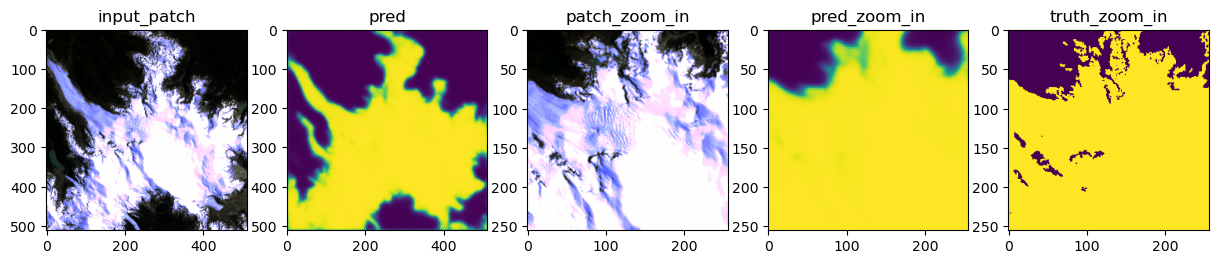

Ep20: tra-> Loss:0.088,Oa:0.944,Miou:0.907, val-> Loss:0.112,Oa:0.914, Miou:0.817,time:1.8s
Ep21: tra->Loss:0.111,Oa:0.905,Miou:0.843,                                 time:1.1s
Ep22: tra->Loss:0.073,Oa:0.945,Miou:0.882,                                 time:1.1s
Ep23: tra-> Loss:0.097,Oa:0.942,Miou:0.889, val-> Loss:0.101,Oa:0.916, Miou:0.826,time:1.8s
Ep24: tra->Loss:0.093,Oa:0.941,Miou:0.889,                                 time:1.1s
Ep25: tra->Loss:0.107,Oa:0.937,Miou:0.880,                                 time:1.0s
Ep26: tra-> Loss:0.088,Oa:0.955,Miou:0.912, val-> Loss:0.110,Oa:0.912, Miou:0.841,time:1.8s
Ep27: tra->Loss:0.103,Oa:0.951,Miou:0.909,                                 time:1.0s
Ep28: tra->Loss:0.080,Oa:0.945,Miou:0.866,                                 time:0.9s
Ep29: tra-> Loss:0.078,Oa:0.930,Miou:0.883, val-> Loss:0.104,Oa:0.901, Miou:0.848,time:1.6s
Ep30: tra->Loss:0.101,Oa:0.922,Miou:0.879,                                 time:1.0s
Ep31: tra->Loss:0.075,Oa:0.966,Miou:0

<Figure size 640x480 with 0 Axes>

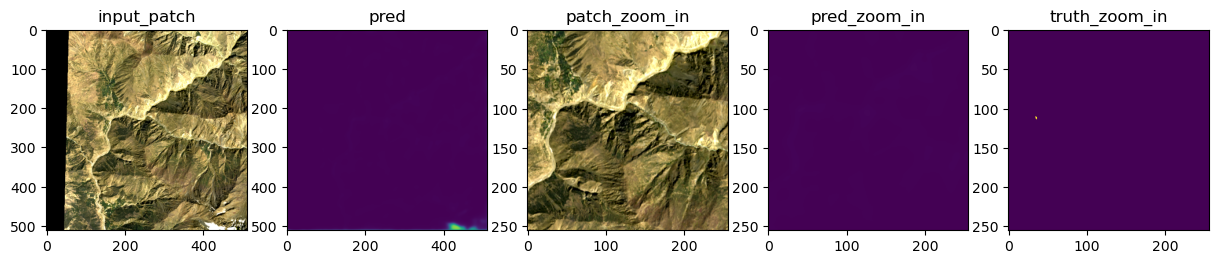

Ep40: tra->Loss:0.056,Oa:0.971,Miou:0.926,                                 time:1.2s
Ep41: tra-> Loss:0.090,Oa:0.960,Miou:0.912, val-> Loss:0.084,Oa:0.913, Miou:0.859,time:1.9s
Ep42: tra->Loss:0.099,Oa:0.952,Miou:0.903,                                 time:1.2s
Ep43: tra->Loss:0.067,Oa:0.949,Miou:0.918,                                 time:1.0s
Ep44: tra-> Loss:0.074,Oa:0.928,Miou:0.885, val-> Loss:0.069,Oa:0.936, Miou:0.885,time:2.0s
Ep45: tra->Loss:0.063,Oa:0.946,Miou:0.913,                                 time:1.2s
Ep46: tra->Loss:0.076,Oa:0.932,Miou:0.890,                                 time:1.2s
Ep47: tra-> Loss:0.061,Oa:0.949,Miou:0.906, val-> Loss:0.065,Oa:0.939, Miou:0.892,time:1.9s
Ep48: tra->Loss:0.050,Oa:0.967,Miou:0.939,                                 time:1.2s
Ep49: tra->Loss:0.057,Oa:0.963,Miou:0.917,                                 time:1.2s
Ep50: tra-> Loss:0.069,Oa:0.952,Miou:0.902, val-> Loss:0.118,Oa:0.895, Miou:0.847,time:2.0s
Ep51: tra->Loss:0.067,Oa:0.967,Miou:0

<Figure size 640x480 with 0 Axes>

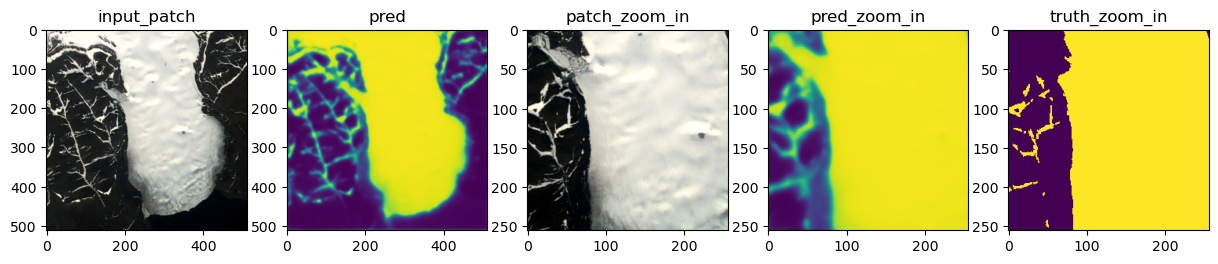

Ep60: tra->Loss:0.104,Oa:0.949,Miou:0.899,                                 time:1.2s
Ep61: tra->Loss:0.083,Oa:0.947,Miou:0.890,                                 time:1.1s
Ep62: tra-> Loss:0.076,Oa:0.938,Miou:0.902, val-> Loss:0.082,Oa:0.917, Miou:0.863,time:2.1s
Ep63: tra->Loss:0.074,Oa:0.964,Miou:0.907,                                 time:1.0s
Ep64: tra->Loss:0.055,Oa:0.948,Miou:0.902,                                 time:1.2s
Ep65: tra-> Loss:0.068,Oa:0.962,Miou:0.924, val-> Loss:0.062,Oa:0.948, Miou:0.897,time:2.2s
Ep66: tra->Loss:0.054,Oa:0.967,Miou:0.899,                                 time:1.1s
Ep67: tra->Loss:0.056,Oa:0.961,Miou:0.917,                                 time:1.2s
Ep68: tra-> Loss:0.075,Oa:0.965,Miou:0.898, val-> Loss:0.059,Oa:0.948, Miou:0.901,time:1.9s
Ep69: tra->Loss:0.052,Oa:0.964,Miou:0.931,                                 time:1.2s
Ep70: tra->Loss:0.054,Oa:0.970,Miou:0.921,                                 time:1.3s
Ep71: tra-> Loss:0.050,Oa:0.977,Miou:0.940, 

<Figure size 640x480 with 0 Axes>

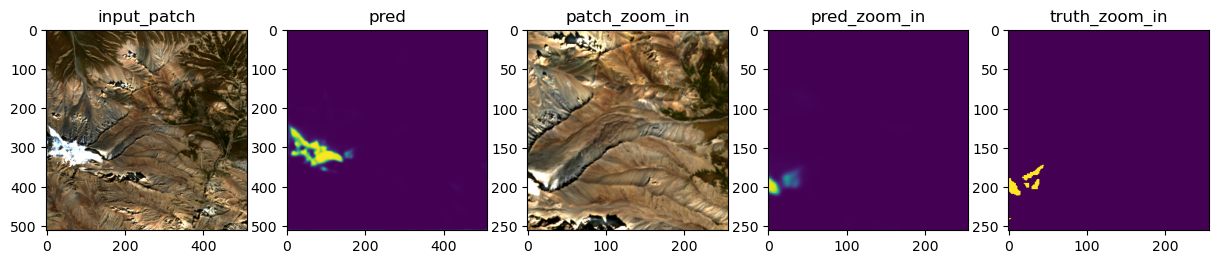

Ep80: tra-> Loss:0.049,Oa:0.973,Miou:0.930, val-> Loss:0.054,Oa:0.952, Miou:0.906,time:2.0s
Ep81: tra->Loss:0.051,Oa:0.973,Miou:0.944,                                 time:1.1s
Ep82: tra->Loss:0.069,Oa:0.964,Miou:0.934,                                 time:1.3s
Ep83: tra-> Loss:0.065,Oa:0.963,Miou:0.929, val-> Loss:0.067,Oa:0.926, Miou:0.886,time:2.0s
Ep84: tra->Loss:0.050,Oa:0.961,Miou:0.923,                                 time:1.0s
Ep85: tra->Loss:0.043,Oa:0.965,Miou:0.921,                                 time:1.2s
Ep86: tra-> Loss:0.061,Oa:0.952,Miou:0.918, val-> Loss:0.061,Oa:0.939, Miou:0.900,time:2.4s
Ep87: tra->Loss:0.052,Oa:0.944,Miou:0.905,                                 time:1.2s
Ep88: tra->Loss:0.053,Oa:0.960,Miou:0.935,                                 time:1.5s
Ep89: tra-> Loss:0.056,Oa:0.961,Miou:0.931, val-> Loss:0.053,Oa:0.950, Miou:0.907,time:2.1s
Ep90: tra->Loss:0.045,Oa:0.945,Miou:0.910,                                 time:1.3s
Ep91: tra->Loss:0.045,Oa:0.977,Miou:0

<Figure size 640x480 with 0 Axes>

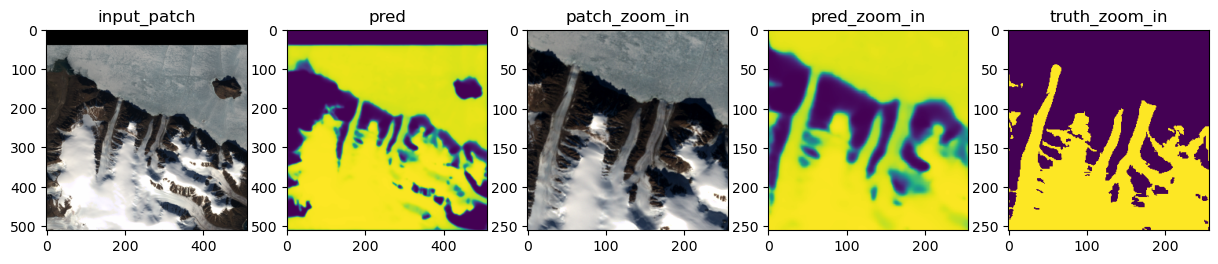

Ep100: tra->Loss:0.087,Oa:0.949,Miou:0.903,                                 time:1.2s
Ep101: tra-> Loss:0.091,Oa:0.947,Miou:0.903, val-> Loss:0.108,Oa:0.923, Miou:0.864,time:2.2s
Ep102: tra->Loss:0.075,Oa:0.936,Miou:0.908,                                 time:1.3s
Ep103: tra->Loss:0.104,Oa:0.919,Miou:0.876,                                 time:1.3s
Ep104: tra-> Loss:0.090,Oa:0.923,Miou:0.881, val-> Loss:0.095,Oa:0.928, Miou:0.868,time:2.1s
Ep105: tra->Loss:0.062,Oa:0.957,Miou:0.924,                                 time:1.1s
Ep106: tra->Loss:0.071,Oa:0.956,Miou:0.909,                                 time:1.1s
Ep107: tra-> Loss:0.064,Oa:0.956,Miou:0.918, val-> Loss:0.086,Oa:0.925, Miou:0.872,time:2.0s
Ep108: tra->Loss:0.065,Oa:0.952,Miou:0.923,                                 time:1.5s
Ep109: tra->Loss:0.060,Oa:0.924,Miou:0.895,                                 time:1.2s
Ep110: tra-> Loss:0.058,Oa:0.969,Miou:0.939, val-> Loss:0.086,Oa:0.911, Miou:0.869,time:2.1s
Ep111: tra->Loss:0.070,Oa:

<Figure size 640x480 with 0 Axes>

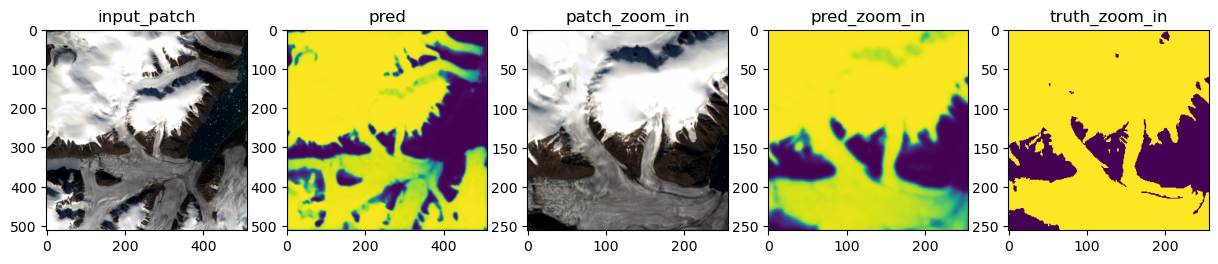

Ep120: tra->Loss:0.054,Oa:0.965,Miou:0.922,                                 time:1.2s
Ep121: tra->Loss:0.063,Oa:0.963,Miou:0.932,                                 time:1.1s
Ep122: tra-> Loss:0.052,Oa:0.970,Miou:0.924, val-> Loss:0.055,Oa:0.956, Miou:0.906,time:2.0s
Ep123: tra->Loss:0.058,Oa:0.954,Miou:0.915,                                 time:1.2s
Ep124: tra->Loss:0.058,Oa:0.944,Miou:0.898,                                 time:1.3s
Ep125: tra-> Loss:0.081,Oa:0.948,Miou:0.910, val-> Loss:0.098,Oa:0.923, Miou:0.871,time:1.9s
Ep126: tra->Loss:0.081,Oa:0.950,Miou:0.908,                                 time:1.1s
Ep127: tra->Loss:0.062,Oa:0.977,Miou:0.923,                                 time:1.2s
Ep128: tra-> Loss:0.058,Oa:0.966,Miou:0.914, val-> Loss:0.052,Oa:0.956, Miou:0.910,time:2.1s
Ep129: tra->Loss:0.048,Oa:0.979,Miou:0.952,                                 time:1.1s
Ep130: tra->Loss:0.067,Oa:0.938,Miou:0.897,                                 time:1.3s
Ep131: tra-> Loss:0.045,Oa:0.968,

<Figure size 640x480 with 0 Axes>

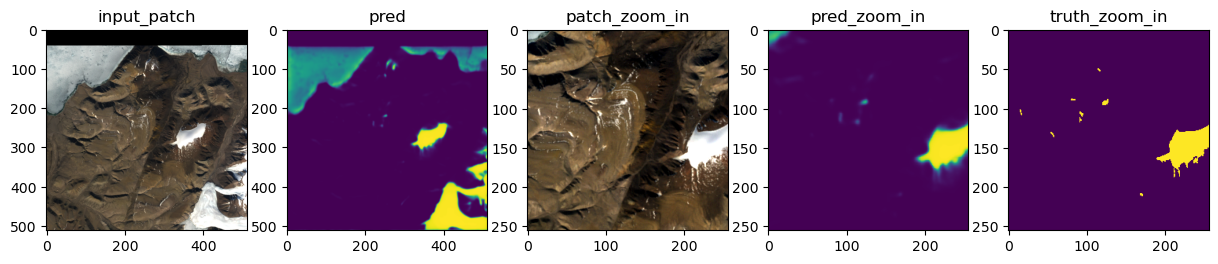

Ep140: tra-> Loss:0.104,Oa:0.931,Miou:0.890, val-> Loss:0.098,Oa:0.936, Miou:0.840,time:2.1s
Ep141: tra->Loss:0.084,Oa:0.960,Miou:0.913,                                 time:1.3s
Ep142: tra->Loss:0.049,Oa:0.953,Miou:0.921,                                 time:1.1s
Ep143: tra-> Loss:0.062,Oa:0.924,Miou:0.896, val-> Loss:0.058,Oa:0.964, Miou:0.905,time:1.9s
Ep144: tra->Loss:0.055,Oa:0.974,Miou:0.932,                                 time:1.3s
Ep145: tra->Loss:0.047,Oa:0.971,Miou:0.939,                                 time:1.1s
Ep146: tra-> Loss:0.042,Oa:0.980,Miou:0.947, val-> Loss:0.049,Oa:0.960, Miou:0.911,time:2.2s
Ep147: tra->Loss:0.049,Oa:0.931,Miou:0.875,                                 time:1.0s
Ep148: tra->Loss:0.037,Oa:0.969,Miou:0.939,                                 time:1.2s
Ep149: tra-> Loss:0.046,Oa:0.966,Miou:0.940, val-> Loss:0.072,Oa:0.921, Miou:0.878,time:2.1s
Ep150: tra->Loss:0.061,Oa:0.935,Miou:0.906,                                 time:1.2s
Ep151: tra->Loss:0.056,Oa:

<Figure size 640x480 with 0 Axes>

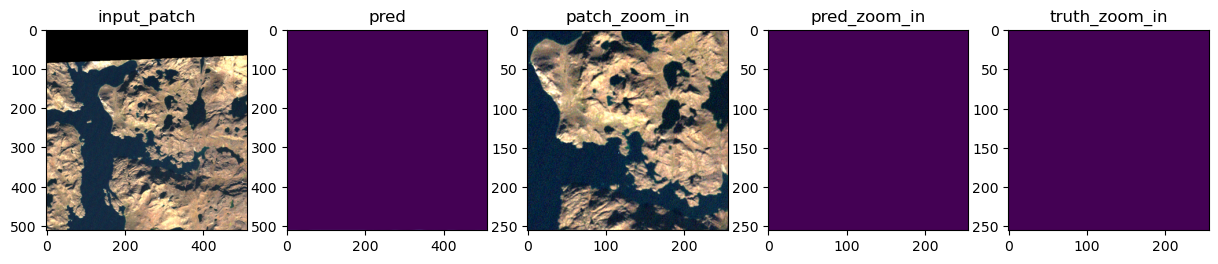

Ep160: tra->Loss:0.063,Oa:0.954,Miou:0.908,                                 time:1.2s
Ep161: tra-> Loss:0.079,Oa:0.957,Miou:0.911, val-> Loss:0.082,Oa:0.926, Miou:0.878,time:2.0s
Ep162: tra->Loss:0.063,Oa:0.925,Miou:0.873,                                 time:1.3s
Ep163: tra->Loss:0.043,Oa:0.945,Miou:0.911,                                 time:1.2s
Ep164: tra-> Loss:0.062,Oa:0.940,Miou:0.900, val-> Loss:0.059,Oa:0.954, Miou:0.907,time:2.1s
Ep165: tra->Loss:0.057,Oa:0.970,Miou:0.939,                                 time:1.4s
Ep166: tra->Loss:0.064,Oa:0.949,Miou:0.901,                                 time:1.2s
Ep167: tra-> Loss:0.075,Oa:0.929,Miou:0.893, val-> Loss:0.054,Oa:0.958, Miou:0.913,time:1.9s
Ep168: tra->Loss:0.078,Oa:0.963,Miou:0.916,                                 time:1.1s
Ep169: tra->Loss:0.062,Oa:0.962,Miou:0.937,                                 time:1.2s
Ep170: tra-> Loss:0.071,Oa:0.936,Miou:0.897, val-> Loss:0.061,Oa:0.927, Miou:0.882,time:2.2s
Ep171: tra->Loss:0.054,Oa:

<Figure size 640x480 with 0 Axes>

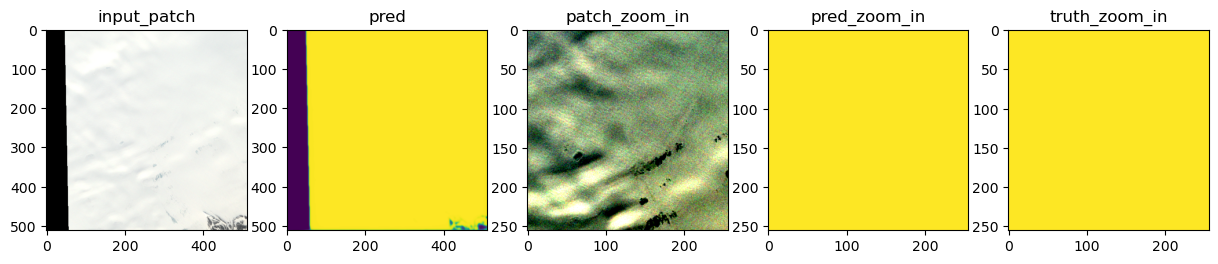

Ep180: tra->Loss:0.070,Oa:0.964,Miou:0.913,                                 time:1.1s
Ep181: tra->Loss:0.049,Oa:0.952,Miou:0.927,                                 time:1.3s
Ep182: tra-> Loss:0.052,Oa:0.969,Miou:0.937, val-> Loss:0.050,Oa:0.958, Miou:0.916,time:2.0s
Ep183: tra->Loss:0.049,Oa:0.965,Miou:0.921,                                 time:1.2s
Ep184: tra->Loss:0.039,Oa:0.970,Miou:0.941,                                 time:1.1s
Ep185: tra-> Loss:0.047,Oa:0.976,Miou:0.948, val-> Loss:0.050,Oa:0.950, Miou:0.917,time:2.1s
Ep186: tra->Loss:0.041,Oa:0.966,Miou:0.931,                                 time:1.2s
Ep187: tra->Loss:0.042,Oa:0.958,Miou:0.935,                                 time:1.3s
Ep188: tra-> Loss:0.042,Oa:0.981,Miou:0.946, val-> Loss:0.048,Oa:0.956, Miou:0.919,time:1.9s
Ep189: tra->Loss:0.046,Oa:0.958,Miou:0.927,                                 time:1.4s
Ep190: tra->Loss:0.035,Oa:0.972,Miou:0.938,                                 time:1.2s
Ep191: tra-> Loss:0.039,Oa:0.946,

<Figure size 640x480 with 0 Axes>

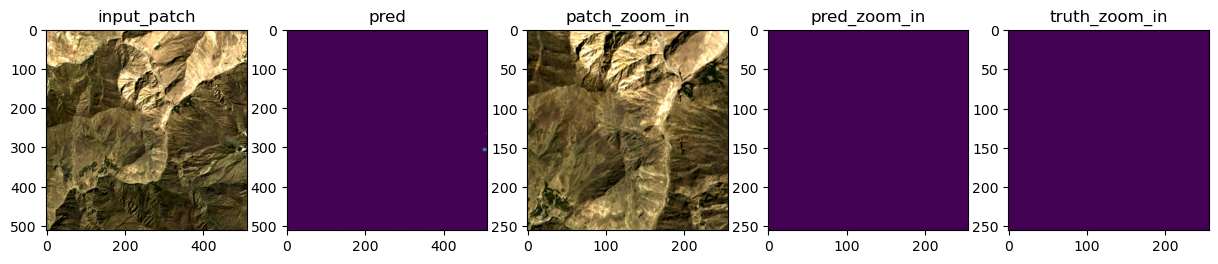

<Figure size 640x480 with 0 Axes>

In [10]:
device = torch.device('cuda:0')  
metrics = train_loops(model=model,  
                epoches=200,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [11]:
# # model saving 
# model_name = 'u2net' 
# # model_name = 'u2net_biatt' 
# # model_name = 'u2net_cbam' 
# # model_name = 'deeplabv3plus'  
# # model_name = 'deeplabv3plus_mb2' 
# date_str = time.strftime("%Y-%m-%d-%H", time.localtime()) 
# date_str = date_str.replace('-', '')  ## remove '-' for file name 
# path_save = f'model/trained/{model_name}/{model_name}_eval_mode.pth' 
# # path_save = f'model/trained/seg_models/{model_name}_weights_{date_str}.pth' 
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# ## model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# ## metrics saving
# path_metrics = f'model/trained/{model_name}/{model_name}_eval_mode_metrics.csv'    
# ## path_metrics = f'model/trained/seg_models/{model_name}_metrics_{date_str}.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
